## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# CHANGE DATA PATH HERE -- INPUT IS KRISH'S CAR DATA FROM 03/2025 AND LATER
data_path = Path("C:/Users/adams/Desktop/data/CAR Data/df_main_cleaned.csv")

df_main = pd.read_csv(data_path, usecols=range(8))

# Week 4: Immigration and HIV Menus (Abandonment)

In [2]:
# CAR DATA – HIV
hiv_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalHIVMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL
df_sessions_hiv = hiv_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions_hiv['Abandoned'] = 'Unknown'
df_sessions_hiv['Reason'] = ''

# CAR DATA – Immigration
imm_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalImmigrationMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL
df_sessions_imm = imm_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions_imm['Abandoned'] = 'Unknown'
df_sessions_imm['Reason'] = ''

In [9]:
# Return the remaining untagged (Abandoned == 'Unknown') sessions along with the corresponding activity rows from the menu dataframe.
def get_remaining_untagged_random(df_sessions, menu_df):
    remaining_ids = df_sessions.loc[df_sessions['Abandoned'] == 'Unknown', 'Contact Session ID'].unique()
    np.random.shuffle(remaining_ids)
    remaining_df = menu_df[menu_df['Contact Session ID'].isin(remaining_ids)].copy()
    remaining_df['Contact Session ID'] = pd.Categorical(remaining_df['Contact Session ID'], categories=remaining_ids, ordered=True)
    return remaining_df.sort_values(['Contact Session ID', 'Activity Start Timestamp']).reset_index(drop=True)


In [10]:
get_remaining_untagged_random(df_sessions_hiv, hiv_df).head(40)

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,49288a44-eae6-4c20-bdba-fe200b622b55,Main Number Telephony EP,NaN,NaN,2024-04-10 14:49:20,NaN,NaN,NaN
1,49288a44-eae6-4c20-bdba-fe200b622b55,NaN,LACMain,NaN,2024-04-10 14:49:20,NaN,NaN,NaN
2,49288a44-eae6-4c20-bdba-fe200b622b55,Main Number Telephony EP,NaN,LanguageSelectionMenu,2024-04-10 14:49:20,NaN,NaN,NaN
3,49288a44-eae6-4c20-bdba-fe200b622b55,Main Number Telephony EP,LACMain,NaN,2024-04-10 14:49:20,NaN,NaN,NaN
4,49288a44-eae6-4c20-bdba-fe200b622b55,Main Number Telephony EP,NaN,MainMenu,2024-04-10 14:49:32,NaN,NaN,NaN
5,49288a44-eae6-4c20-bdba-fe200b622b55,NaN,PreLegalMenuSeniorsMenu,NaN,2024-04-10 14:49:58,NaN,NaN,NaN
6,49288a44-eae6-4c20-bdba-fe200b622b55,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2024-04-10 14:49:58,NaN,NaN,NaN
7,49288a44-eae6-4c20-bdba-fe200b622b55,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsConfirmationMenu,2024-04-10 14:50:06,NaN,NaN,NaN
8,49288a44-eae6-4c20-bdba-fe200b622b55,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SuburbsOrCityMenu,2024-04-10 14:50:22,NaN,NaN,NaN
9,49288a44-eae6-4c20-bdba-fe200b622b55,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsADAPTMenu,2024-04-10 14:50:42,NaN,NaN,NaN


In [3]:
# NEW HELPER FUNCTIONS - These weren't used for Employment, but are needed for HIV & Immigration

def mark_not_abandoned_last_row_queue(df_sessions, menu_df, queue_name, reason):
    """Mark Not Abandoned if the last row's Queue Name matches."""
    ids_to_mark = []
    for session_id, group in menu_df.sort_values(
        ['Contact Session ID', 'Activity Start Timestamp']
    ).groupby('Contact Session ID'):

        group = group.reset_index(drop=True)

        if len(group) == 0:
            continue

        if group.iloc[-1]['Queue Name'] == queue_name:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark)
        & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Not Abandoned', reason]


def mark_abandoned_last_row_activity(df_sessions, menu_df, activity_name, reason):
    """Mark sessions Abandoned if the last row's Activity Name matches."""
    ids_to_mark = [
        sid for sid, group in menu_df.groupby('Contact Session ID')
        if not group.empty and group.sort_values('Activity Start Timestamp').iloc[-1]['Activity Name'] == activity_name
    ]
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark)
        & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]


def mark_abandoned_second_last_row_flow(df_sessions, menu_df, last_termination_reason, second_last_flow_name, reason):
    """Mark sessions as Abandoned if last row has Termination Reason AND second-to-last row has Flow Name."""
    ids_to_mark = []
    for session_id, group in menu_df.sort_values(
        ['Contact Session ID', 'Activity Start Timestamp']
    ).groupby('Contact Session ID'):

        group = group.reset_index(drop=True)

        if len(group) < 2:
            continue

        if (
            group.iloc[-1]['Termination Reason'] == last_termination_reason
            and group.iloc[-2]['Flow Name'] == second_last_flow_name
        ):
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark)
        & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]

def mark_abandoned_last_row_ep(df_sessions, menu_df, ep_name, reason):
    """Mark sessions Abandoned if the last row's EP Name matches."""
    ids_to_mark = []
    for session_id, group in menu_df.sort_values(
        ['Contact Session ID', 'Activity Start Timestamp']
    ).groupby('Contact Session ID'):
        
        group = group.reset_index(drop=True)
        if len(group) == 0:
            continue

        if group.iloc[-1]['EP Name'] == ep_name:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark)
        & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]
    
def mark_abandoned_second_last_row_activity(df_sessions, menu_df, second_last_activity_names, reason):
    """Mark sessions Abandoned if the second-to-last row's Activity Name matches any in the list."""
    if isinstance(second_last_activity_names, str):
        second_last_activity_names = [second_last_activity_names]

    ids_to_mark = []
    for session_id, g in menu_df.sort_values(['Contact Session ID','Activity Start Timestamp']).groupby('Contact Session ID'):
        g = g.reset_index(drop=True)
        if len(g) < 2:
            continue
        if g.iloc[-2]['Activity Name'] in second_last_activity_names:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark) &
        (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned','Reason']
    ] = ['Abandoned', reason]

def mark_abandoned_second_last_activity(df_sessions, menu_df, second_last_activities, reason):
    """Mark sessions Abandoned if second-to-last Activity Name matches any in the list."""
    if isinstance(second_last_activities, str):
        second_last_activities = [second_last_activities]

    ids_to_mark = []
    for session_id, group in menu_df.groupby('Contact Session ID'):
        group = group.sort_values('Activity Start Timestamp').reset_index(drop=True)
        if len(group) < 2:
            continue
        if group.iloc[-2]['Activity Name'] in second_last_activities:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark) & 
        (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]
    
def mark_not_abandoned_nth_last_activity(df_sessions, menu_df, activity_names, reason, position=-2):
    """
    Mark sessions as Not Abandoned if the Nth-to-last Activity Name matches.
    
    position=-1 → last row  
    position=-2 → second-to-last  
    position=-3 → third-to-last, etc.
    """
    if isinstance(activity_names, str):
        activity_names = [activity_names]

    ids_to_mark = []
    for session_id, group in menu_df.groupby('Contact Session ID'):
        group = group.sort_values('Activity Start Timestamp').reset_index(drop=True)
        if len(group) < abs(position):
            continue
        if group.iloc[position]['Activity Name'] in activity_names:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark) &
        (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned','Reason']
    ] = ['Not Abandoned', reason]


In [6]:
# ---- Not Abandoned rules (HIV) ----
mark_not_abandoned(df_sessions_hiv, hiv_df, 'LegalServerScreenPop', 'Callback')
mark_not_abandoned(df_sessions_hiv, hiv_df, 'ClosedQueueMenu', 'Closed Queue')
mark_not_abandoned_position(df_sessions_hiv, hiv_df, ['Closed Hours-Holidays Menu Telephony EP'], 'Closed Hours', position=-1)
mark_not_abandoned_queue(df_sessions_hiv, hiv_df, 'Front Desk Transfer', 'Front Desk Transfer')
mark_not_abandoned_position(df_sessions_hiv, hiv_df, ['Legal Housing Menu Telephony EP','Legal Immigration Menu Telephony EP','Main Number Telephony EP', 'LegalMenu2', 'Other Legal Menu'], reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")
mark_not_abandoned_last_row_queue(df_sessions_hiv, hiv_df, queue_name='HIV Voicemail Transfer', reason='Heard Voicemail')
mark_not_abandoned_position(df_sessions_hiv, hiv_df, ep_names=['All LAC Queues Telephony EP', 'Legal Family Menu Telephony EP', 'Legal Menu Telephony EP', 'Other Legal Menu Telephony EP'], reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")


# Abandoned
mark_abandoned_last_row_activity(df_sessions_hiv, hiv_df, activity_name='HIVMenu', reason='Left HIV Menu')
mark_abandoned_second_last_row(df_sessions_hiv, hiv_df, last_termination_reason='Customer Left', second_last_activity_name='HIVMenu', reason='Left HIV Menu')
mark_abandoned_second_last_row_flow(df_sessions_hiv, hiv_df, 'Customer Left', 'LegalHIVMenu', 'Left HIV Menu')

In [249]:
# ---- Not Abandoned rules (Immigration) ----
mark_not_abandoned(df_sessions_imm, imm_df, 'LegalServerScreenPop', 'Callback')
mark_not_abandoned(df_sessions_imm, imm_df, 'ClosedQueueMenu', 'Closed Queue')
mark_not_abandoned_position(df_sessions_imm, imm_df, ['Closed Hours-Holidays Menu Telephony EP'], 'Closed Hours', position=-1)
mark_not_abandoned_queue(df_sessions_imm, imm_df, 'Front Desk Transfer', 'Front Desk Transfer')
mark_not_abandoned_position(df_sessions_imm, imm_df, ['Legal Menu Telephony EP','Other Legal Menu Telephony EP','Legal Housing Menu Telephony EP','Main Number Telephony EP'], reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")
mark_not_abandoned_last_row_queue(df_sessions_imm, imm_df, queue_name='Trafficking Voicemail Transfer', reason='Heard Voicemail')
mark_not_abandoned_second_last_row_activity(df_sessions_imm, imm_df, 'IntakePreQueueMessage1', 'Reached Intake')
mark_not_abandoned_position(df_sessions_imm, imm_df, ep_names='Pre-Legal Menu Seniors Menu Telephony EP', reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")
mark_not_abandoned_position(df_sessions_imm, imm_df, ep_names='Legal Family Menu Telephony EP', reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")
mark_not_abandoned_position(df_sessions_imm, imm_df, ep_names='Courtesy Callback Telephony EP', reason='Callback', position=-1)
mark_not_abandoned_nth_last_activity(df_sessions_imm, imm_df, 'IntakePreQueueMessage1', 'Reached Intake', position=-3)
mark_not_abandoned_position(df_sessions_imm, imm_df, ep_names='Legal Benefits Menu Telephony EP', reason='Different Menu', position=-1, abandoned_value="Doesn't Apply")

# Abandoned
mark_abandoned_second_last_row_activity(df_sessions_imm, imm_df, 'QueueMenu1', 'Left Queue')
mark_abandoned_second_last_row_activity(df_sessions_imm, imm_df, ['ImmigrationMenu', 'ImmigrationOtherMenu'], 'Left Immigration Menu')
mark_abandoned_second_last_row_flow(df_sessions_imm, imm_df, last_termination_reason='Customer Left', second_last_flow_name='LegalImmigrationMenu', reason='Left Immigration Menu')
mark_abandoned_second_last_activity(df_sessions_imm, imm_df, 'PlayMOH300s', 'Left Queue')
mark_abandoned_last_row_activity(df_sessions_imm, imm_df, 'ImmigrationMenu', 'Left Immigration Menu')



## HIV Results

In [7]:
# HIV RESULTS
df_sessions_hiv.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Left HIV Menu,337
1,Doesn't Apply,Different Menu,233
5,Not Abandoned,Heard Voicemail,836
3,Not Abandoned,Closed Queue,252
2,Not Abandoned,Callback,23
4,Not Abandoned,Front Desk Transfer,6
6,Unknown,,420


In [251]:
# Summary table
summary_hiv = df_sessions_hiv['Abandoned'].value_counts(dropna=False).reset_index()
summary_hiv.columns = ['Abandoned', 'Count']
summary_hiv['Percent'] = (summary_hiv['Count'] / summary_hiv['Count'].sum() * 100).round(2)
summary_hiv = summary_hiv.sort_values(by='Abandoned')
summary_hiv

,Abandoned,Count,Percent
1,Abandoned,291,38.39
2,Doesn't Apply,98,12.93
0,Not Abandoned,369,48.68


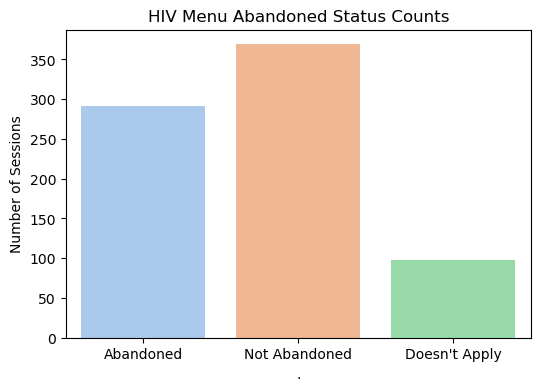

In [252]:
# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions_hiv, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('HIV Menu Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

## Immigration Results

In [250]:
# IMMIGRATION RESULTS
df_sessions_imm.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Left Immigration Menu,234
1,Abandoned,Left Queue,18
2,Doesn't Apply,Different Menu,29
4,Not Abandoned,Closed Queue,748
3,Not Abandoned,Callback,70
6,Not Abandoned,Heard Voicemail,46
7,Not Abandoned,Reached Intake,9
5,Not Abandoned,Front Desk Transfer,2


In [253]:
# Summary table
summary_imm = df_sessions_imm['Abandoned'].value_counts(dropna=False).reset_index()
summary_imm.columns = ['Abandoned', 'Count']
summary_imm['Percent'] = (summary_imm['Count'] / summary_imm['Count'].sum() * 100).round(2)
summary_imm = summary_imm.sort_values(by='Abandoned')
summary_imm

,Abandoned,Count,Percent
1,Abandoned,252,21.80
2,Doesn't Apply,29,2.51
0,Not Abandoned,875,75.69


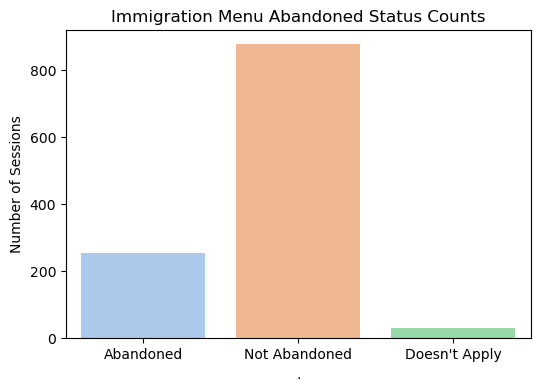

In [254]:
# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions_imm, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('Immigration Menu Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

# Week 3: Employment Abandonment Analysis

## Iteration

In [ ]:
# CAR DATA -
employ_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalEmploymentMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL (unique Contact Session ID)
df_sessions = employ_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions['Abandoned'] = 'Unknown'
df_sessions['Reason'] = ''

In [6]:
# RUN THIS CODE TO SEE UN-IDENTIFIED CALL DATA, SO THEN YOU CAN DETERMINE NEW RULES TO MARK AS ABANDONED VERSUS NOT ABANDONED
# RANDOMIZED ORDER SO YOU CAN EXPLORE DIFFERENT CALLS

unknown_ids = df_sessions.loc[df_sessions['Abandoned'] == 'Unknown', 'Contact Session ID']
unknown_df = employ_df[employ_df['Contact Session ID'].isin(unknown_ids)].copy()

# Randomize the order of the contact session IDs
shuffled_ids = np.random.permutation(unknown_ids)

unknown_df['Contact Session ID'] = pd.Categorical(
    unknown_df['Contact Session ID'],
    categories=shuffled_ids,
    ordered=True
)

unknown_df = unknown_df.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
)

unknown_df.head(60)

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [7]:
unknown_df['Contact Session ID'].nunique()

0

In [4]:
# ---------------- Helper Functions ----------------

def mark_not_abandoned(df_sessions, employ_df, activity_name, reason):
    """Mark sessions as Not Abandoned if any row has the specified Activity Name."""
    ids = employ_df.loc[employ_df['Activity Name'] == activity_name, 'Contact Session ID'].unique()
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Not Abandoned', reason]


def mark_abandoned(df_sessions, employ_df, termination_reason, ep_name, reason):
    """Mark sessions as Abandoned if any row has the specified Termination Reason and EP Name."""
    ids = employ_df.loc[
        (employ_df['Termination Reason'] == termination_reason) & 
        (employ_df['EP Name'] == ep_name), 
        'Contact Session ID'
    ].unique()
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]


def mark_abandoned_last_row(df_sessions, employ_df, termination_reason, queue_name, reason):
    """Mark sessions as Abandoned if any row has the specified Termination Reason and Queue Name."""
    ids = employ_df.loc[
        (employ_df['Termination Reason'] == termination_reason) & 
        (employ_df['Queue Name'] == queue_name),
        'Contact Session ID'
    ].unique()
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]


def mark_not_abandoned_position(df_sessions, employ_df, ep_names, reason, position=-1, abandoned_value='Not Abandoned'):
    """
    Mark sessions based on EP Name at a specific position in session.
    position=-1 means last row, -2 means second-to-last row, etc.
    abandoned_value: value to set in Abandoned column (default 'Not Abandoned')
    """
    if isinstance(ep_names, str):
        ep_names = [ep_names]

    ids_to_mark = []
    for session_id, group in employ_df.sort_values(['Contact Session ID','Activity Start Timestamp']).groupby('Contact Session ID'):
        group = group.reset_index(drop=True)
        if len(group) < abs(position):
            continue
        if group.iloc[position]['EP Name'] in ep_names:
            ids_to_mark.append(session_id)

    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = [abandoned_value, reason]


def mark_abandoned_second_last_row(df_sessions, employ_df, last_termination_reason, second_last_activity_name, reason):
    """Mark sessions as Abandoned if last row has Termination Reason and second-to-last row has Activity Name."""
    ids_to_mark = []
    for session_id, group in employ_df.sort_values(['Contact Session ID','Activity Start Timestamp']).groupby('Contact Session ID'):
        group = group.reset_index(drop=True)
        if len(group) < 2: continue
        if group.iloc[-1]['Termination Reason'] == last_termination_reason and group.iloc[-2]['Activity Name'] == second_last_activity_name:
            ids_to_mark.append(session_id)
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids_to_mark) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Abandoned', reason]


def mark_not_abandoned_queue(df_sessions, employ_df, queue_name, reason):
    """Mark sessions as Not Abandoned if any row has the specified Queue Name."""
    ids = employ_df.loc[employ_df['Queue Name'] == queue_name, 'Contact Session ID'].unique()
    df_sessions.loc[
        df_sessions['Contact Session ID'].isin(ids) & (df_sessions['Abandoned'] == 'Unknown'),
        ['Abandoned', 'Reason']
    ] = ['Not Abandoned', reason]


# ---------------- Apply Rules ----------------

# ---- Not Abandoned rules ----
mark_not_abandoned(df_sessions, employ_df, 'LegalServerScreenPop', 'Callback') #callback
mark_not_abandoned(df_sessions, employ_df, 'ClosedQueueMenu', 'Closed Queue') # closed queue
mark_not_abandoned_position(df_sessions, employ_df, ['Closed Hours-Holidays Menu Telephony EP'], 'Closed Hours', position=-1) # closed hours
mark_not_abandoned_queue(df_sessions, employ_df, 'Front Desk Transfer', 'Front Desk Transfer') # front desk transfer
mark_not_abandoned_position(
    df_sessions, employ_df,
    [
        'Legal Menu Telephony EP', 
        'Other Legal Menu Telephony EP',
        'Legal Housing Menu Telephony EP', 
        'Legal Immigration Menu Telephony EP', 
        'Main Number Telephony EP'
    ],
    reason='Different Menu',  # Ended in different menu
    position=-1,
    abandoned_value="Doesn't Apply"
)
mark_not_abandoned_position(df_sessions, employ_df, 'Legal Menu Telephony EP', 'Different Menu', position=-2, abandoned_value="Doesn't Apply")
# Also ended in different menu, but second to last row

# ---- Abandoned rules ----
mark_abandoned_second_last_row(df_sessions, employ_df, 'Customer Left', 'IntakePreQueueMessage1', 'Left PreQueue Message')
mark_abandoned(df_sessions, employ_df, 'Customer Left', 'Legal Employment Menu Telephony EP', 'Customer Left Employment Menu')
mark_abandoned_last_row(df_sessions, employ_df, 'Customer Left', 'Employment', 'Customer Left Employment Queue')
mark_abandoned_last_row(df_sessions, employ_df, 'Customer Left', 'Employment SP', 'Customer Left Employment Queue')
# Left queue, menu or pre-queue message


NameError: name 'df_sessions' is not defined

In [8]:
df_sessions['Abandoned'].value_counts()

Not Abandoned    1769
Abandoned         116
Doesn't Apply      34
Name: Abandoned, dtype: int64

In [9]:
summary = df_sessions['Abandoned'].value_counts(dropna=False).reset_index()
summary.columns = ['Abandoned', 'Count']
summary['Percent'] = (summary['Count'] / summary['Count'].sum() * 100).round(2)
summary = summary.sort_values(by='Abandoned')  # sort alphabetically by Abandoned
summary

,Abandoned,Count,Percent
1,Abandoned,116,6.04
2,Doesn't Apply,34,1.77
0,Not Abandoned,1769,92.18


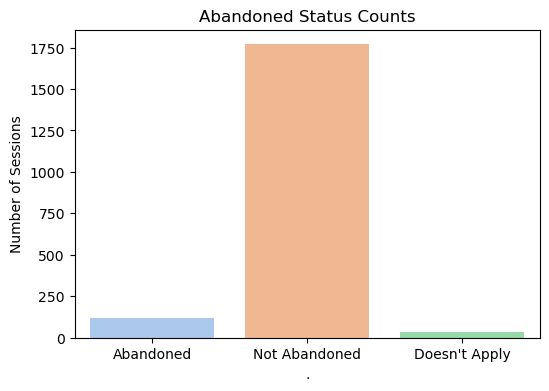

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

In [11]:
df_sessions.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Customer Left Employment Menu,80
1,Abandoned,Customer Left Employment Queue,26
2,Abandoned,Left PreQueue Message,10
3,Doesn't Apply,Different Menu,34
6,Not Abandoned,Closed Queue,1490
4,Not Abandoned,Callback,276
7,Not Abandoned,Front Desk Transfer,2
5,Not Abandoned,Closed Hours,1


## Verbiage Analysis 1: Voicemail vs. Not Voicemail (Week 2)

In [3]:
# OBJECTIVE: Determine, of all calls, how many lead to the clinic voicemail as opposed to anything other than a voicemail
# REASON: Gain additional information on whether it may be worthy to put option 4 (leads to a voicemail) before option 3 (does not lead to a voicemail)

# Get the final (latest) row for each Contact Session ID
df_last = (
    df_main.sort_values('Activity Start Timestamp')
           .groupby('Contact Session ID', as_index=False)
           .last()
)

# Check how many have missing Queue Name
missing_queue = df_last['Queue Name'].isna().sum()
print(f"Number of calls with missing final Queue Name: {missing_queue}")

# Exclude those missing values ---
df_last_valid = df_last.dropna(subset=['Queue Name'])

# Create flags for voicemail vs other ---
df_last_valid['Call Type'] = df_last_valid['Queue Name'].apply(
    lambda x: 'Voicemail' if x == 'Clinic Voicemail Transfer' else 'Other'
)

# Count totals and proportions ---
call_counts = df_last_valid['Call Type'].value_counts()
call_proportions = df_last_valid['Call Type'].value_counts(normalize=True) * 100

print("\n--- Call Counts ---")
print(call_counts)

print("\n--- Call Proportions (%) ---")
print(call_proportions.round(2))

# See top non-voicemail destinations ---
top_queues = (
    df_last_valid[df_last_valid['Call Type'] == 'Other']['Queue Name']
    .value_counts()
    .head(20)
)
print("\n--- Top 10 Non-Voicemail Queue Names ---")
print(top_queues)

Number of calls with missing final Queue Name: 103385

--- Call Counts ---
Other        51971
Voicemail    18174
Name: Call Type, dtype: int64

--- Call Proportions (%) ---
Other        74.09
Voicemail    25.91
Name: Call Type, dtype: float64

--- Top 10 Non-Voicemail Queue Names ---
Staff Directory English Transfer       19602
Front Desk Transfer                    12386
Intake Outdial Queue                    6753
Staff Directory Spanish Transfer        3000
Criminal Records Voicemail Transfer     1608
Family                                  1203
SubSenior Other                          827
Consumer                                 818
Housing                                  665
HIV Voicemail Transfer                   646
SubSenior Benefits                       527
Benefits                                 504
SubSenior Tenant                         490
SubSenior Consumer                       362
SubSenior Family                         328
Employment                              

In [4]:
# Investigate cause of all the unknown final queues

missing_queues_sessions = df_last[df_last['Queue Name'].isna()]['Contact Session ID']
termination_summary = (
    df_main[df_main['Contact Session ID'].isin(missing_queues_sessions)]
    ['Termination Reason']
    .value_counts()
)
print(termination_summary)

Customer Left                      9369
System disconnected the contact     741
NO_ANSWER_FROM_CUSTOMER              50
System Error                         28
Name: Termination Reason, dtype: int64


## Verbiage Analysis 2: Complaint/Compliment Menu (Week 2)

In [5]:
# OBJECTIVE: Determine how many calls reached compliment/complaint menu, and how many of these actually used an agent's time
# FIRST ATTEMPT: Flawed (look at following code for my final and better analysis)

# Filter to calls from March 16, 2025 onward
df_filtered = df_main[df_main['Activity Start Timestamp'] >= '2025-03-16']

# Find all calls that reached the Compliment or Complaint menu
complaint_calls = df_filtered[df_filtered['Activity Name'] == 'ComplimentOrComplaintMenu']

# Get unique Contact Session IDs for those calls
complaint_call_ids = complaint_calls['Contact Session ID'].unique()

# Subset full dataset to just those sessions
subset = df_filtered[df_filtered['Contact Session ID'].isin(complaint_call_ids)]

# Group by Contact Session ID and see which sessions ever had an Agent Name
grouped = subset.groupby('Contact Session ID')['Agent Name'].apply(lambda x: x.notna().any())

# Results
num_total = len(grouped)
num_with_agent = grouped.sum()
num_without_agent = num_total - num_with_agent

print(f"Total calls that reached Compliment/Complaint Menu: {num_total}")
print(f"Calls where an Agent Name appeared (spoke to agent): {num_with_agent}")
print(f"Calls where no Agent Name appeared (likely voicemail/no agent): {num_without_agent}")

# Optional: percentage
print(f"Percent that reached an agent: {num_with_agent / num_total * 100:.2f}%")

subset.head(160)

Total calls that reached Compliment/Complaint Menu: 63
Calls where an Agent Name appeared (spoke to agent): 28
Calls where no Agent Name appeared (likely voicemail/no agent): 35
Percent that reached an agent: 44.44%


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
2088449,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088450,d474178a-c0ac-475d-8b13-3340a5211c00,NaN,LACMain,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088451,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-18 10:36:37,NaN,NaN,NaN
2088452,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,LACMain,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088453,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,MainMenu,2025-03-18 10:36:45,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2107994,c56d406f-73c4-4ce3-a176-a24806767f4d,NaN,Queues,NaN,2025-03-20 12:02:09,NaN,NaN,NaN
2107995,c56d406f-73c4-4ce3-a176-a24806767f4d,NaN,ClosedQueueMenu,NaN,2025-03-20 12:02:09,NaN,NaN,NaN
2107996,c56d406f-73c4-4ce3-a176-a24806767f4d,Closed Queue Menu Telephony EP,NaN,ClosedQueueMenu,2025-03-20 12:02:09,NaN,NaN,NaN
2108006,c56d406f-73c4-4ce3-a176-a24806767f4d,Closed Queue Menu Telephony EP,NaN,NaN,2025-03-20 12:02:55,NaN,NaN,Customer Left


In [6]:
import pandas as pd

# 1. Filter to March 16, 2025 onwards
df_filtered = df_main[df_main['Activity Start Timestamp'] >= '2025-03-16'].copy()

# Make sure timestamps are in datetime format
df_filtered['Activity Start Timestamp'] = pd.to_datetime(df_filtered['Activity Start Timestamp'])

# 2. Sort by session and timestamp to maintain order
df_filtered = df_filtered.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# 3. Find all Compliment/Complaint menu entries
complaint_entries = df_filtered[df_filtered['Activity Name'] == 'ComplimentOrComplaintMenu']

valid_sessions = []

# 4. For each such session, check if MainMenu appears within 60 seconds *after* Compliment/Complaint
for session_id, group in df_filtered.groupby('Contact Session ID'):
    complaint_times = group.loc[group['Activity Name'] == 'ComplimentOrComplaintMenu', 'Activity Start Timestamp']
    if complaint_times.empty:
        continue

    # For each time they entered the Compliment/Complaint menu
    backed_out = False
    for t in complaint_times:
        # Find any 'MainMenu' activity within 60 seconds *after* this timestamp
        back_to_main = group[
            (group['Activity Name'] == 'MainMenu') &
            (group['Activity Start Timestamp'] > t) &
            (group['Activity Start Timestamp'] <= t + pd.Timedelta(seconds=60))
        ]
        if not back_to_main.empty:
            backed_out = True
            break

    # Keep only those who did NOT go back to main within 1 minute
    if not backed_out:
        valid_sessions.append(session_id)

# 5. Subset to those sessions
subset = df_filtered[df_filtered['Contact Session ID'].isin(valid_sessions)]

# 6. Check whether they ever had an agent
grouped = subset.groupby('Contact Session ID')['Agent Name'].apply(lambda x: x.notna().any())

# 7. Summaries
num_total = len(grouped)
num_with_agent = grouped.sum()
num_without_agent = num_total - num_with_agent

print(f"Total sessions that stayed in Compliment/Complaint (did not return to Main Menu): {num_total}")
print(f"Sessions with an Agent Name (spoke to agent): {num_with_agent}")
print(f"Sessions without an Agent Name (likely voicemail): {num_without_agent}")
print(f"Percent that reached an agent: {num_with_agent / num_total * 100:.2f}%")

Total sessions that stayed in Compliment/Complaint (did not return to Main Menu): 17
Sessions with an Agent Name (spoke to agent): 15
Sessions without an Agent Name (likely voicemail): 2
Percent that reached an agent: 88.24%


In [11]:
# Create a dataframe of only the calls that passed the filter
survivor_data = df_filtered[df_filtered['Contact Session ID'].isin(valid_sessions)].copy()

# Sort by session and time for readability
survivor_data = survivor_data.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Display the first few rows neatly
print("Sample of surviving compliment/complaint sessions:")
display_cols = [
    'Contact Session ID',
    'Activity Start Timestamp',
    'Activity Name',
    'Queue Name',
    'Agent Name',
    'Termination Reason'
]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(survivor_data[display_cols])


Sample of surviving compliment/complaint sessions:


,Contact Session ID,Activity Start Timestamp,Activity Name,Queue Name,Agent Name,Termination Reason
2098846,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098847,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098848,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,LanguageSelectionMenu,NaN,NaN,NaN
2098850,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098851,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:29,MainMenu,NaN,NaN,NaN
2098874,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:22,ComplimentOrComplaintMenu,NaN,NaN,NaN
2098882,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,FrontDeskTransfer2,NaN,NaN,NaN
2098883,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,NaN,Front Desk Transfer,NaN,NaN
2098884,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,NaN,NaN,NaN,NaN
2098885,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:46,NaN,Front Desk Transfer,CBT Agent,NaN
